## Model 6: Transformer + sentencepiece tokenizer

In [ ]:
import pandas as pd
from datasets import Dataset
import sentencepiece as spm

In [ ]:

train_df = pd.read_excel("train.xlsx")
valid_df = pd.read_excel("valid.xlsx")
test_df  = pd.read_excel("test.xlsx")

train_df.shape, valid_df.shape, test_df.shape

((5701, 2), (1222, 2), (1222, 2))

In [ ]:
dataset = Dataset.from_pandas(train_df)
dataset

Dataset({
    features: ['Tweet', 'Label'],
    num_rows: 5701
})

In [ ]:
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for t in dataset["Tweet"]:
        f.write(t + "\n")


In [ ]:
spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="tweet_sp",
    vocab_size=16000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)


In [ ]:
sp = spm.SentencePieceProcessor()
sp.load("tweet_sp.model")


True

In [ ]:
sp.get_piece_size()


16000

In [ ]:
example_text = "I took paracetamol 💊 yesterday!"
token_ids = sp.encode(example_text, out_type=int)
token_ids


[6724, 398, 1185, 4431, 15834, 1, 2771, 15910]

In [ ]:
tokens = sp.encode(example_text, out_type=str)
tokens


['▁I', '▁took', '▁par', 'acetamol', '▁', '💊', '▁yesterday', '!']

In [ ]:
train_texts = train_df["Tweet"].tolist()
train_labels = train_df["Label"].tolist()

valid_texts = valid_df["Tweet"].tolist()
valid_labels = valid_df["Label"].tolist()
VOCAB_SIZE = sp.get_piece_size()

In [ ]:
import torch
from torch.utils.data import Dataset

MAX_LEN = 64

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = sp.encode(self.texts[idx], out_type=int)
        ids = ids[:MAX_LEN]
        ids += [0] * (MAX_LEN - len(ids))  # pad

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [ ]:

from torch.utils.data import Dataset, DataLoader
import math

train_ds = TweetDataset(train_texts, train_labels)
valid_ds = TweetDataset(valid_texts, valid_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)


In [ ]:
import torch.nn as nn
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [ ]:
class TweetTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes=3,
        d_model=256,
        n_heads=8,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids):
        # input_ids: (B, L)
        padding_mask = (input_ids == 0)

        x = self.embed(input_ids)
        x = self.pos_enc(x)

        x = self.encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        # mean pooling (ignore padding)
        mask = (~padding_mask).unsqueeze(-1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1)

        return self.classifier(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TweetTransformer(vocab_size=VOCAB_SIZE).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)


In [ ]:
import torch
from sklearn.metrics import f1_score

num_epochs = 10

train_losses = []
val_losses = []
val_f1s = []

for epoch in range(num_epochs):

    # =====================
    # TRAIN
    # =====================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # =====================
    # VALIDATION
    # =====================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    val_macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )
    val_f1s.append(val_macro_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch [1/10] | Train Loss: 0.9789 | Val Loss: 0.9131 | Val Macro F1: 0.4194
Epoch [2/10] | Train Loss: 0.8667 | Val Loss: 0.8983 | Val Macro F1: 0.4665
Epoch [3/10] | Train Loss: 0.7607 | Val Loss: 0.8766 | Val Macro F1: 0.5586
Epoch [4/10] | Train Loss: 0.6409 | Val Loss: 0.9980 | Val Macro F1: 0.5490
Epoch [5/10] | Train Loss: 0.5035 | Val Loss: 1.0501 | Val Macro F1: 0.5542
Epoch [6/10] | Train Loss: 0.3755 | Val Loss: 1.2356 | Val Macro F1: 0.5638
Epoch [7/10] | Train Loss: 0.2650 | Val Loss: 1.5392 | Val Macro F1: 0.5355
Epoch [8/10] | Train Loss: 0.1796 | Val Loss: 1.7304 | Val Macro F1: 0.5650
Epoch [9/10] | Train Loss: 0.1353 | Val Loss: 2.1627 | Val Macro F1: 0.5310
Epoch [10/10] | Train Loss: 0.1202 | Val Loss: 2.0929 | Val Macro F1: 0.5203


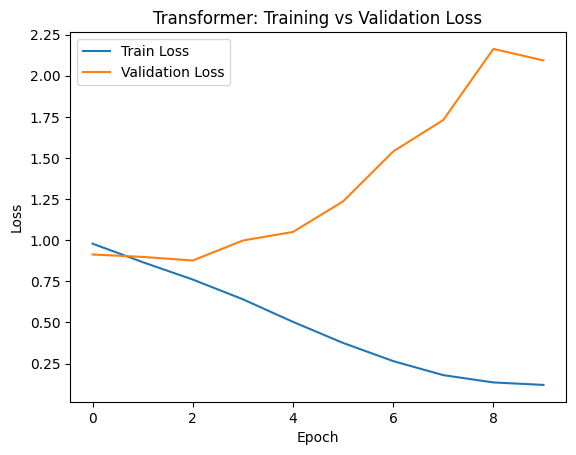

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Transformer: Training vs Validation Loss")
plt.show()


### creating next word in sequence


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Load text
with open("words.txt", "r", encoding="utf-8") as f:
    text = f.read().strip()

tokens = text.split()
print("Total tokens:", len(tokens))

FileNotFoundError: [Errno 2] No such file or directory: 'words.txt'

In [ ]:
vocab = sorted(set(tokens))
stoi = {w:i for i,w in enumerate(vocab)}
itos = {i:w for w,i in stoi.items()}

encoded = torch.tensor([stoi[w] for w in tokens], dtype=torch.long)

vocab_size = len(vocab)
print("Vocab size:", vocab_size)

Vocab size: 2173


In [ ]:
SEQ_LEN = 16

class WordDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

dataset = WordDataset(encoded, SEQ_LEN)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(SEQ_LEN, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device)
        x = self.embed(x) + self.pos(pos)
        x = self.transformer(x)
        return self.fc(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerLM(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = loss_fn(logits.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")

Epoch 1 | Loss: 7.6728
Epoch 2 | Loss: 7.1821
Epoch 3 | Loss: 6.6046
Epoch 4 | Loss: 5.9274
Epoch 5 | Loss: 5.2092
Epoch 6 | Loss: 4.5045
Epoch 7 | Loss: 3.8224
Epoch 8 | Loss: 3.1633
Epoch 9 | Loss: 2.5362
Epoch 10 | Loss: 1.9631


In [ ]:
@torch.no_grad()
def predict_next(model, seed, k=5):
    model.eval()
    ids = torch.tensor([stoi[w] for w in seed.split()], device=device).unsqueeze(0)

    logits = model(ids)
    probs = torch.softmax(logits[0, -1], dim=0)

    topk = torch.topk(probs, k)
    return [(itos[i.item()], p.item()) for i, p in zip(topk.indices, topk.values)]


predict_next(model, "mdma dose")

[('doses', 0.18534965813159943),
 ('haha', 0.004189636092633009),
 ('trafficking', 0.0035793762654066086),
 ('perspective', 0.0032338581513613462),
 ('brief', 0.0032062737736850977)]